In [94]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split

from torchinfo import summary

from torchvision.io import read_video
from torchvision import transforms
from torchvision.datasets import DatasetFolder

import os
import cv2
import numpy as np 
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, ConfusionMatrixDisplay

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
def load_video(path, num_frames=16, size=(128, 128)):
    frames = []
    cap = cv2.VideoCapture(path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_len = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in frames_len:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frame = torch.tensor(frame).permute(2, 0, 1)
        frames.append(frame)
        
    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])

    return torch.stack(frames, dim=0)
        

In [4]:
transformer = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop((128, 128)),   
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                        
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomCrop(128),
])

In [5]:
link = "/kaggle/input/datasets/maks9213/infantry-data/infantry"
dataset = DatasetFolder(
    root = link,
    loader = load_video,
    extensions = ("mp4", "avi"),
    transform = transformer
)

In [6]:
classes = dataset.classes
classes

['advance', 'disperse', 'halt', 'regroup', 'retreat']

In [7]:
x, y = dataset[0]
x = x[0, :, :, :]
x.shape

torch.Size([3, 128, 128])

In [8]:
def output(limit, dataset):
    classes = dataset.classes
    for i, (x, y) in enumerate(dataset):
        if i+1 == limit:
            break

        x = x[0, :, :, :].permute(1, 2, 0).cpu().numpy()

        plt.imshow(x)
        title = classes[int(y)]
        plt.title(title)
        plt.axis('off')
        plt.show()

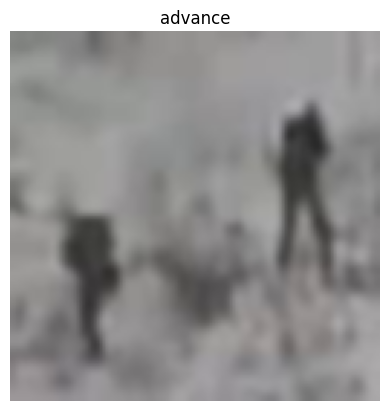

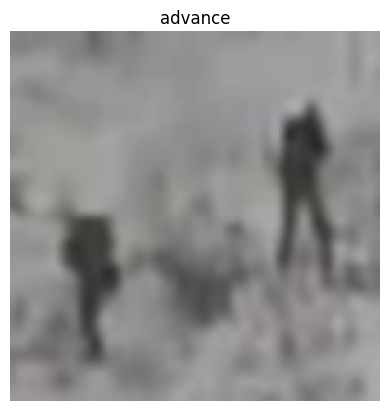

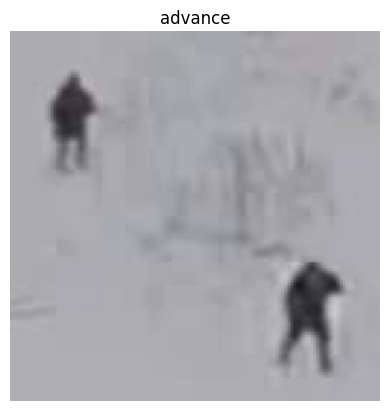

In [9]:
output(4, dataset)

In [10]:
def compute_dense_optical_flow(frames):
    assert frames.ndim == 4
    assert frames.shape[-1] == 3

    flows = []

    prev_grays = cv2.cvtColor(frames[0], cv2.COLOR_RGB2GRAY)
    for t in range(1, frames.shape[0]):
        curr_gray = cv2.cvtColor(frames[t], cv2.COLOR_RGB2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_grays,
            curr_gray,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        flows.append(flow)
        prev_grays = curr_gray

    return np.stack(flows, axis=0)

In [11]:
os.makedirs("flow_cache", exist_ok=True)

for idx in tqdm(range(len(dataset))):
    video, label = dataset[idx]

    if isinstance(video, torch.Tensor):
        if video.shape[1] == 3:
            video = video.permute(0, 2, 3, 1)
        video = video.numpy()

    if video.dtype != np.uint8:
        video = (video * 255).astype(np.uint8)

    flows = compute_dense_optical_flow(video)

    dx = flows[..., 0]
    dy = flows[..., 1]
    mag = np.sqrt(dx**2 + dy**2)
    
    T, H, W = dx.shape
    
    features = []
    
    for t in range(T):
    
        frame_features = []
    
        for i in range(2):
            for j in range(2):
    
                y0 = i * H // 2
                y1 = (i + 1) * H // 2
                x0 = j * W // 2
                x1 = (j + 1) * W // 2
    
                dx_patch = dx[t, y0:y1, x0:x1]
                dy_patch = dy[t, y0:y1, x0:x1]
                mag_patch = mag[t, y0:y1, x0:x1]
    
                frame_features.extend([
                    dx_patch.mean(),
                    dy_patch.mean(),
                    mag_patch.mean()
                ])
    
        features.append(frame_features)
    
    flow_seq = np.array(features)

    torch.save(
        {
            "x": torch.tensor(flow_seq, dtype=torch.float32),
            "y": label
        },
        f"flow_cache/{idx}.pt"
    )

100%|██████████| 2548/2548 [06:54<00:00,  6.15it/s]


In [12]:
class CahcedFlowDataset(Dataset):
    def __init__(self, cache_dir, dataset):
        self.cache_dir = cache_dir
        self.files = sorted(os.listdir(self.cache_dir))
        self.classes = dataset.classes
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(os.path.join(self.cache_dir, self.files[idx]))
        x = data['x']
        y = torch.tensor(data['y'])
        return x, y

In [13]:
cache_link = '/kaggle/working/flow_cache'
data = CahcedFlowDataset(cache_link, dataset)

indices = np.random.permutation(len(data))
split = int(0.9 * len(indices))

train_idx = indices[:split]
val_idx   = indices[split:]

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)

In [15]:
len(train_data), len(val_data)

(2293, 255)

In [43]:
batch_size = 64
train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [44]:
x, y = next(iter(train_dl))
x.shape, y.shape

(torch.Size([64, 15, 12]), torch.Size([64]))

In [16]:
x, y = train_data[0]
x.shape, y

(torch.Size([15, 12]), tensor(2))

In [70]:
class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = self.attn(x)
        weights = torch.softmax(weights, dim=1)

        return (weights * x).sum(dim=1)

In [74]:
class Net(nn.Module):
    def __init__(self, layers=3, hidden_size=256, feature_dim=12, bidirectional=True, num_classes=5):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size = hidden_size,
            num_layers = layers,
            batch_first = True,
            bidirectional = bidirectional
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        self.ta = TemporalAttention(out_dim)
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        lstm_out, (_, _) = self.lstm(x)
        out = self.ta(lstm_out)
        out = self.classifier(out)

        return out

    def predict(self, x):
        self.eval()

        with torch.no_grad():
            out = self.forward(x)

        res = torch.argmax(out, dim=1)
        return res.item()
        

In [75]:
model = Net()
tensor = torch.randn(64, 15, 12)
out = model(tensor)
out.shape

torch.Size([64, 5])

In [76]:
summary(model, input_data=torch.randn(1, 15, 12))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 5]                    --
├─LSTM: 1-1                              [1, 15, 512]              3,706,880
├─TemporalAttention: 1-2                 [1, 512]                  --
│    └─Linear: 2-1                       [1, 15, 1]                513
├─Linear: 1-3                            [1, 5]                    2,565
Total params: 3,709,958
Trainable params: 3,709,958
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 55.61
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 14.84
Estimated Total Size (MB): 14.90

In [77]:
model = Net()
tensor = torch.randn(1, 15, 12)
out = model.predict(tensor)
out

4

In [79]:
def train(model, train_dl, val_dl, optimizer, loss_fn, epochs, device):
    history = {
        'train_loss': [],
        'train_acc': [],
        'train_f1': [],

        'val_loss': [],
        'val_acc': [],
        'val_f1': []
    }


    for epoch in range(epochs):

        model.train()
        train_loss = 0.0
        
        total = 0
        correct = 0

        all_preds = []
        all_labels = []

        for x, y in tqdm(train_dl):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())
            
            

        total_train_loss = train_loss / len(train_dl)
        total_train_acc = correct / total
        total_train_f1 = f1_score(all_labels, all_preds, average="macro")


        model.eval()
        val_loss = 0.0
        
        total = 0
        correct = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for x, y in tqdm(val_dl):
                x = x.to(device)
                y = y.to(device)

                out = model(x)

                loss = loss_fn(out, y)
                val_loss += loss.item()

                preds = torch.argmax(out, dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(y.detach().cpu().numpy()) 

        total_val_loss = val_loss / len(val_data)
        total_val_acc = correct / total
        total_val_f1 = f1_score(all_labels, all_preds, average="macro")


        history['train_loss'].append(total_train_loss)
        history['train_acc'].append(total_train_acc)
        history['train_f1'].append(total_train_f1)
        
        history['val_loss'].append(total_val_loss)
        history['val_acc'].append(total_val_acc)
        history['val_f1'].append(total_val_f1)

        print(f"Epoch {epoch+1}: train_loss: {total_train_loss:.4f}, train_acc: {total_train_acc:.4f}, train_f1: {total_train_f1:.4f}, val_loss: {total_val_loss:.4f}, val_acc: {total_val_acc:.4f}, val_f1: {total_val_f1:.4f}")

    return history

        

            

    

In [80]:
model.to(device)

Net(
  (lstm): LSTM(12, 256, num_layers=3, batch_first=True, bidirectional=True)
  (ta): TemporalAttention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Linear(in_features=512, out_features=5, bias=True)
)

In [82]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 15

In [83]:
history = train(model, train_dl, val_dl, optimizer, loss_fn, epochs, device)

100%|██████████| 4/4 [00:00<00:00, 37.35it/s]


Epoch 1: train_loss: 1.4481, train_acc: 0.3585, train_f1: 0.3388, val_loss: 0.0185, val_acc: 0.5412, val_f1: 0.5300


100%|██████████| 4/4 [00:00<00:00, 37.01it/s]


Epoch 2: train_loss: 0.9834, train_acc: 0.6001, train_f1: 0.5969, val_loss: 0.0144, val_acc: 0.6431, val_f1: 0.6422


100%|██████████| 4/4 [00:00<00:00, 37.69it/s]


...

Epoch 13: train_loss: 0.2984, train_acc: 0.8910, train_f1: 0.8908, val_loss: 0.0084, val_acc: 0.8118, val_f1: 0.8100


100%|██████████| 4/4 [00:00<00:00, 37.16it/s]


Epoch 14: train_loss: 0.2651, train_acc: 0.9084, train_f1: 0.9081, val_loss: 0.0066, val_acc: 0.8627, val_f1: 0.8652


100%|██████████| 4/4 [00:00<00:00, 36.82it/s]

Epoch 15: train_loss: 0.2448, train_acc: 0.9163, train_f1: 0.9158, val_loss: 0.0062, val_acc: 0.8745, val_f1: 0.8715


In [90]:
def output_metrics(history, name):
    plt.plot(history[f'train_{name}'], label='training')
    plt.plot(history[f'val_{name}'], label='validation')
    plt.ylabel(name)
    plt.xlabel('Epochs')
    plt.title(name)
    plt.legend()

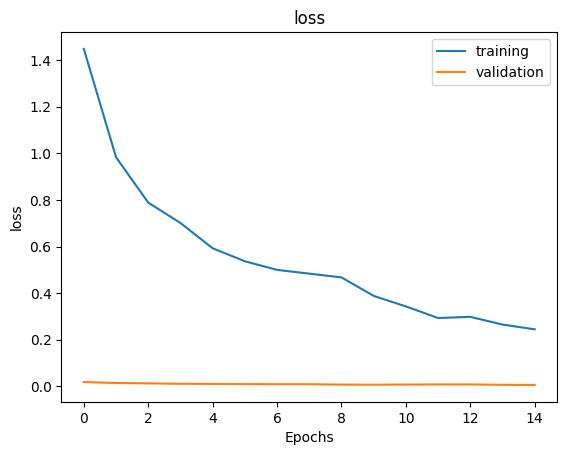

In [91]:
output_metrics(history, 'loss')

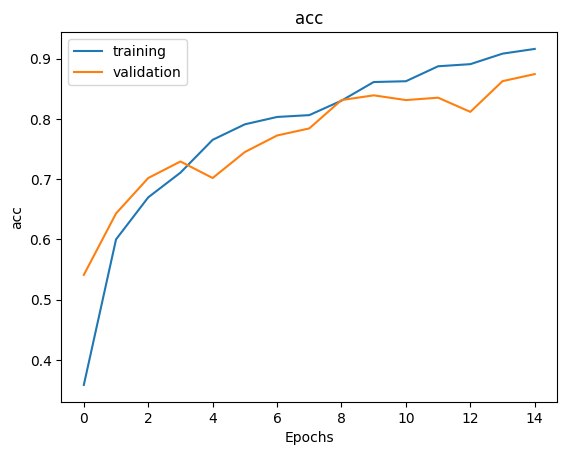

In [92]:
output_metrics(history, 'acc')

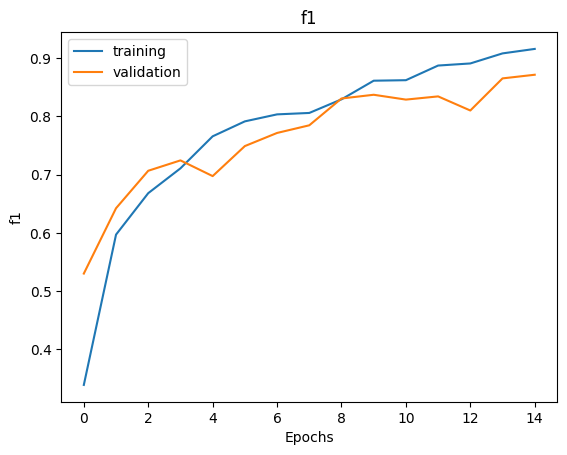

In [93]:
output_metrics(history, 'f1')

In [95]:
classes

['advance', 'disperse', 'halt', 'regroup', 'retreat']

100%|██████████| 4/4 [00:00<00:00, 36.66it/s]


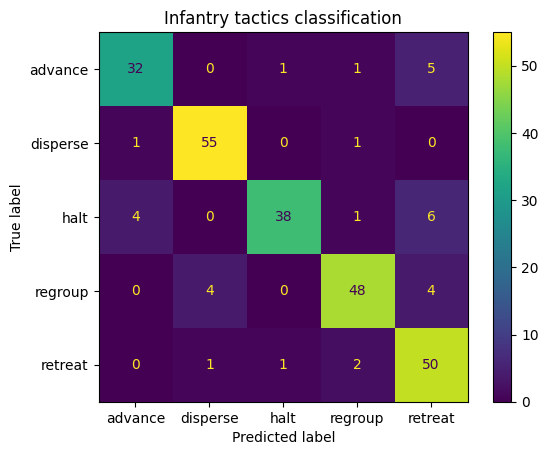

In [97]:
y_true = []
y_preds = []

model.eval()

with torch.no_grad():
    for x, y in tqdm(val_dl):
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        pred = torch.argmax(out, dim=1).cpu().numpy()
        y_preds.extend(pred)

        y = y.cpu().numpy()
        y_true.extend(y)

y_true = np.array(y_true)
y_preds = np.array(y_preds)

ConfusionMatrixDisplay.from_predictions(y_true, y_preds, display_labels=classes)
plt.title("Infantry tactics classification")
plt.show()

In [98]:
torch.save(model.state_dict(), 'infantry_model.pt')